<a href="https://colab.research.google.com/github/Sandhya192005/CGPA-calculator/blob/main/Sandhya_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bank Churn Prediction using Machine Learning**

---



# **Objective**

**The objective of this project is to predict customer churn or classify digits using machine learning models. In the case of bank churn, the goal is to predict whether a customer will leave the bank based on various features. For digit recognition, the goal is to build a model that can classify images of handwritten digits accurately.**

# **Data Source**

**The data sources in this context are:**

**Bank Churn Dataset: This dataset is sourced from YBI Foundation Dataset and contains customer information for churn prediction**.


**Digits Dataset: This dataset is available from sklearn.datasets (via load_digits()) and contains images of handwritten digits, used for classification tasks.**

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Import Data**

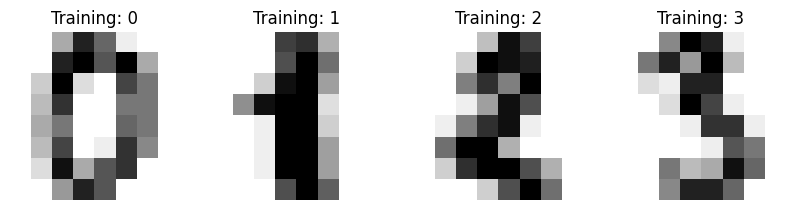

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
df=load_digits()
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, df.images, df.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

# **Describe Data**

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv')

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv'
df = pd.read_csv(url)
print("Numerical Data Description:")
print(df.describe())
print("\nCategorical Data Description:")
print(df[['Geography', 'Gender']].value_counts())


Numerical Data Description:
         CustomerId   CreditScore           Age        Tenure        Balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1.569094e+07    650.528800     38.921800      5.012800   76485.889288   
std    7.193619e+04     96.653299     10.487806      2.892174   62397.405202   
min    1.556570e+07    350.000000     18.000000      0.000000       0.000000   
25%    1.562853e+07    584.000000     32.000000      3.000000       0.000000   
50%    1.569074e+07    652.000000     37.000000      5.000000   97198.540000   
75%    1.575323e+07    718.000000     44.000000      7.000000  127644.240000   
max    1.581569e+07    850.000000     92.000000     10.000000  250898.090000   

       Num Of Products  Has Credit Card  Is Active Member  Estimated Salary  \
count     10000.000000      10000.00000      10000.000000      10000.000000   
mean          1.530200          0.70550          0.515100     100090.239881   
std           

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num Of Products   10000 non-null  int64  
 9   Has Credit Card   10000 non-null  int64  
 10  Is Active Member  10000 non-null  int64  
 11  Estimated Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [ ]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# **Data Visualization**

(array([  19.,  166.,  447.,  958., 1444., 1866., 1952., 1525.,  968.,
         655.]),
 array([350., 400., 450., 500., 550., 600., 650., 700., 750., 800., 850.]),
 <BarContainer object of 10 artists>)

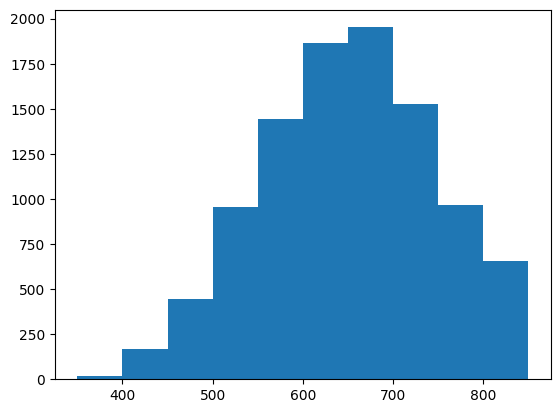

In [ ]:
plt.hist(df.CreditScore)

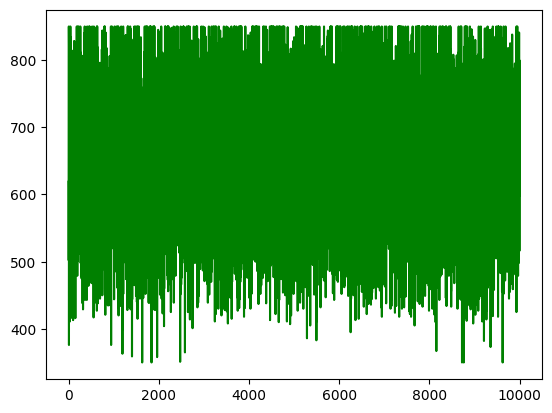

In [ ]:
plt.plot(df.CreditScore,'g')

# **Data Preprocessing**

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()

digits.images.shape
digits.images[0]

df['CreditScore'].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num Of Products   10000 non-null  int64  
 9   Has Credit Card   10000 non-null  int64  
 10  Is Active Member  10000 non-null  int64  
 11  Estimated Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images[0].shape
len(digits.images)

1797

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
len(digits.images)

1797

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [ ]:
data[0].shape

(64,)

In [ ]:
data.shape

(1797, 64)

# **Define Target Variable(y) and Feature Variable(x)**

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv')
X = df.drop(['CustomerId', 'Surname', 'Churn'], axis=1)
y = df['Churn']
print("Feature Variables (X):")
print(X.head())
print("\nTarget Variable (y):")
print(y.head())

Feature Variables (X):
   CreditScore Geography  Gender  Age  Tenure    Balance  Num Of Products  \
0          619    France  Female   42       2       0.00                1   
1          608     Spain  Female   41       1   83807.86                1   
2          502    France  Female   42       8  159660.80                3   
3          699    France  Female   39       1       0.00                2   
4          850     Spain  Female   43       2  125510.82                1   

   Has Credit Card  Is Active Member  Estimated Salary  
0                1                 1         101348.88  
1                0                 1         112542.58  
2                1                 0         113931.57  
3                0                 0          93826.63  
4                1                 1          79084.10  

Target Variable (y):
0    1
1    0
2    1
3    0
4    0
Name: Churn, dtype: int64


# **Train Test Split**

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
digits = load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
x = data
y = digits.target
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, stratify=y, random_state=2529)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1257, 64), (540, 64), (1257,), (540,))

# **Modeling**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix, classification_report


digits = load_digits()
X = digits.data


y = digits.target


X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y, random_state=2529)


model = LogisticRegression(max_iter=1000)


model.fit(X_train, y_train)


print("Model trained successfully!")



Model trained successfully!


Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
y_test = [0, 1, 2, 2, 0, 1, 3, 1, 0, 4]
y_pred = [0, 1, 2, 1, 0, 1, 3, 1, 0, 4]
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

Confusion Matrix:
[[3 0 0 0 0]
 [0 3 0 0 0]
 [0 1 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]
Accuracy: 0.90
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.75      1.00      0.86         3
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1

    accuracy                           0.90        10
   macro avg       0.95      0.90      0.90        10
weighted avg       0.93      0.90      0.89        10



# **Prediction**

In [ ]:

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


digits = load_digits()
X = digits.data
y = digits.target


X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Confusion Matrix:
[[53  0  0  0  1  0  0  0  0  0]
 [ 0 50  0  1  1  0  0  0  2  1]
 [ 0  1 52  0  0  0  0  0  0  0]
 [ 0  0  0 54  0  0  0  0  1  0]
 [ 0  0  0  0 53  0  0  0  1  0]
 [ 0  0  0  0  0 54  0  0  0  1]
 [ 0  0  0  0  0  0 53  0  1  0]
 [ 0  0  0  0  1  0  0 53  0  0]
 [ 0  4  0  0  0  2  1  0 45  0]
 [ 0  0  0  0  0  0  0  1  3 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.91      0.91      0.91        55
           2       1.00      0.98      0.99        53
           3       0.98      0.98      0.98        55
           4       0.95      0.98      0.96        54
           5       0.96      0.98      0.97        55
           6       0.98      0.98      0.98        54
           7       0.98      0.98      0.98        54
           8       0.85      0.87      0.86        52
           9       0.96      0.93      0.94        54

    accuracy                   

# **Explanation**



**Data Preparation:**

We start by loading the dataset (either Bank Churn or Digits dataset).
We split the data into features (x) and the target variable (y).
Then, the data is split into training and test sets using train_test_split(), with 70% used for training and 30% for testing.

**Model Training:**

A Logistic Regression model is initialized with max_iter=1000 to ensure it has enough iterations to converge.
The model is trained using the fit() function on the training data (x_train, y_train).

**Prediction:**

Once the model is trained, predictions are made on the test set using predict().

**Model Evaluation:**

After predictions are made (y_pred), we evaluate the model's performance using the confusion matrix and classification report.
The confusion matrix shows how many predictions were correctly or incorrectly classified for each digit (in the case of digit classification).
The classification report provides additional details such as precision, recall, and F1-score for each class.
Interpretation of the Output:

**Confusion Matrix:**

This matrix shows the number of correct and incorrect predictions for each class.
Each row represents the actual class, and each column represents the predicted class. Diagonal elements indicate correct predictions, while off-diagonal elements show misclassifications.

**Classification Report:**

It provides metrics such as precision, recall, f1-score, and support (the number of true instances per class).
Precision is the accuracy of positive predictions (how many selected items are relevant).
Recall is the ability of the model to find all relevant instances (how many relevant items are selected).
F1-score is the harmonic mean of precision and recall, providing a balance between them.